# Implementation of a Deep Asset Liability Management Environment

In [11]:
import os
import sys
import numpy as np
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))
from environment.config import markov_config
from environment.bond import Bond
from environment.env import DeepALMEnv
from models.utils import print_bond_universe, plot_learning_curve, plot_final_wealth
from models.source.a2c import evaluate_a2c_agent, evaluate_a2c_alm
from models.DirichletPolicy import DirichletActorCriticPolicy
from typing import Callable

In [12]:
TRAINING = True
DIRICHLET = False

# Create logging directory
if DIRICHLET:
    log_dir = "tmp_log/A2C/Dirichlet/"
    os.makedirs(log_dir, exist_ok=True)
else:
    log_dir = "tmp_log/A2C/Gaussian/"
    os.makedirs(log_dir, exist_ok=True)

## Gym Wrapper for SB3 compatibility

In [13]:
# Create and display bond universe
bonds = [Bond(**cfg) for cfg in markov_config["bond_configs"]]
K = len(bonds)
print_bond_universe(bonds)

# Initialize Training Environment
env = DummyVecEnv([lambda: Monitor(
    DeepALMEnv(markov_config=markov_config, seed=None, use_dirichlet=DIRICHLET), 
    filename=os.path.join(log_dir, "monitor.csv"), 
    info_keywords=('nav',)
)])


-----------------------------------------------
| Bond Type            | Maturity (Months)    |
-----------------------------------------------
| 1M_Bill              | 1                    |
| 3M_ZeroCoupon        | 3                    |
| 6M_ZeroCoupon        | 6                    |
| 12M_6Months          | 12                   |
| 24M_6Months          | 24                   |
-----------------------------------------------


In [14]:
model = A2C(
    policy=DirichletActorCriticPolicy,
    env=env,

    learning_rate=0.000489002535998535,
    
    n_steps=64,

    gamma=1.0,         # No discounting: only care about terminal utility
    gae_lambda=0.95,

    use_sde=False,
    sde_sample_freq=4,
    ent_coef=6.297762063806713e-07,


    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        log_std_init=-2, 
    ),

    verbose=1,
    device="auto"
)

Using cpu device


In [ ]:
if TRAINING:
    print("Starting A2C training...")
    model.learn(total_timesteps=1_000_000, log_interval=10)
    print("Training completed.")
    model.save("saved_models/a2c_alm.zip")
else:
    print("Loading pre-trained model...")
    model = A2C.load("saved_models/a2c_alm.zip")
    
env.training = False
env.norm_reward = False

Starting A2C training...


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 10.9     |
|    ep_rew_mean        | -0.993   |
| time/                 |          |
|    fps                | 277      |
|    iterations         | 10       |
|    time_elapsed       | 2        |
|    total_timesteps    | 640      |
| train/                |          |
|    entropy_loss       | 5.59     |
|    explained_variance | -25.8    |
|    learning_rate      | 0.000489 |
|    n_updates          | 9        |
|    policy_loss        | -2.05    |
|    value_loss         | 0.744    |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 11.1     |
|    ep_rew_mean        | -1.01    |
| time/                 |          |
|    fps                | 380      |
|    iterations         | 20       |
|    time_elapsed       | 3        |
|    total_timesteps    | 1280     |
| train/                |          |
|

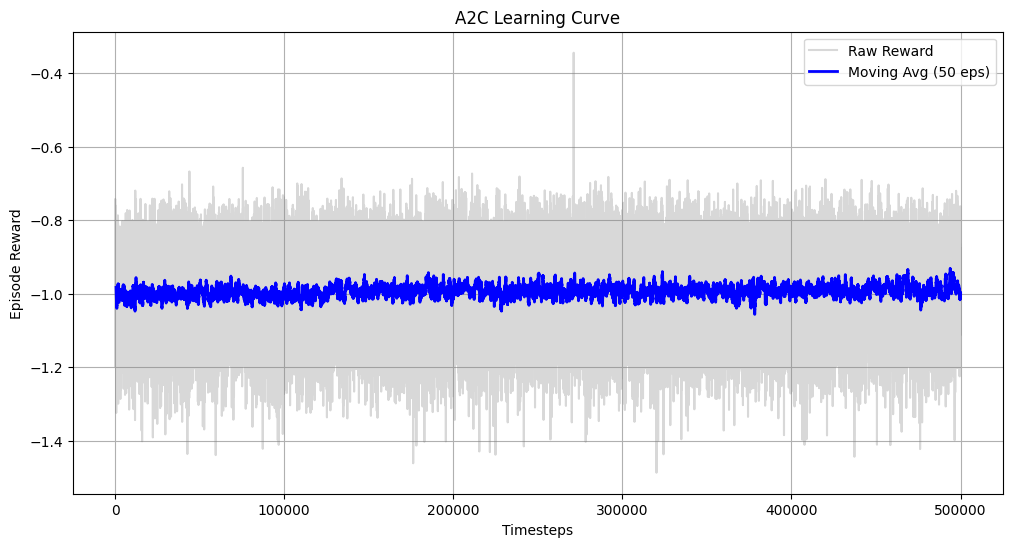

In [16]:
if TRAINING:
    plot_learning_curve(log_dir, "A2C Learning Curve")

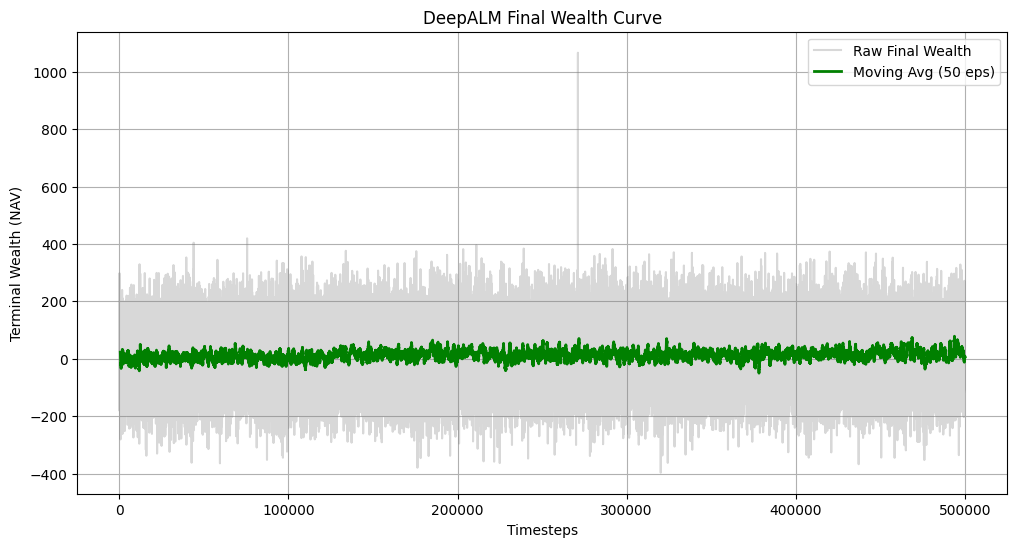

In [17]:
if TRAINING:
    plot_final_wealth(log_dir)

In [18]:
# Single-episode evaluation
print("\nRunning Single Episode Deep Dive")
evaluate_a2c_agent(model, markov_config, K, seed=0, verbose=True);


Running Single Episode Deep Dive
Month 1:
1M Bond Lots: None
3M Bond Lots: None
6M Bond Lots: None
12M Bond Lots: None
24M Bond Lots: None
  Current Market Yields
    1M: 1.96%
    3M: 2.54%
    6M: 2.90%
    12M: 3.13%
    24M: 3.29%
  Cash Before Action: 2000.00
  Inflows: 0.00  |  Liability Due: 59.29  |  Next Liability: 59.29
  Cash After Action: 637.32
  LCR: 15.0739  |  Utility: -0.47
  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  | Bond Type       |        1M        2M        3M        4M        5M        6M        7M        8M        9M       10M       11M       12M       13M       14M       15M       16M       17M       18M       19M       20M       21M       22M       23M       24M |      Total |
  -----------------------------------------------

In [19]:
# Robust out-of-sample statistical evaluation
model = A2C.load("saved_models/a2c_alm.zip")
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_a2c_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=2000,                
    seed_offset=1000001,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting A2C Evaluation ---
Ep 0 | Month  1 | NAV:   687.71 | LCR: 19.55 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   700.92 | LCR:  6.59 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   693.55 | LCR:  8.80 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   694.79 | LCR:  6.08 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   704.75 | LCR:  2.61 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   699.22 | LCR:  6.90 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   715.02 | LCR:  4.10 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   723.82 | LCR:  2.07 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   713.43 | LCR:  2.09 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   729.01 | LCR:  1.27 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   217.59 | LCR:  0.62 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   -12.88 | LCR:  0.00 | Step Reward: -1.01

=== A2C Evaluation Results ===
Mean NAV:       20.78 ± 115.32
Median NAV:     24.91
Min / Max NAV:  -308.86 / 370.29
VaR (5%):       -174.27
CVaR (5%):

In [20]:
model = A2C.load("saved_models/a2c_alm.zip")
print("\nRunning Out-Of-Sample Evaluation")
eval_metrics, eval_raw_results = evaluate_a2c_alm(
    model=model,                       
    markov_config=markov_config,       
    eval_episodes=100_000,                
    seed_offset=1000001,               
    verbose_first_episode=True         
)


Running Out-Of-Sample Evaluation

--- Starting A2C Evaluation ---
Ep 0 | Month  1 | NAV:   687.71 | LCR: 19.55 | Step Reward: 0.00
Ep 0 | Month  2 | NAV:   700.92 | LCR:  6.59 | Step Reward: 0.00
Ep 0 | Month  3 | NAV:   693.55 | LCR:  8.80 | Step Reward: 0.00
Ep 0 | Month  4 | NAV:   694.79 | LCR:  6.08 | Step Reward: 0.00
Ep 0 | Month  5 | NAV:   704.75 | LCR:  2.61 | Step Reward: 0.00
Ep 0 | Month  6 | NAV:   699.22 | LCR:  6.90 | Step Reward: 0.00
Ep 0 | Month  7 | NAV:   715.02 | LCR:  4.10 | Step Reward: 0.00
Ep 0 | Month  8 | NAV:   723.82 | LCR:  2.07 | Step Reward: 0.00
Ep 0 | Month  9 | NAV:   713.43 | LCR:  2.09 | Step Reward: 0.00
Ep 0 | Month 10 | NAV:   729.01 | LCR:  1.27 | Step Reward: 0.00
Ep 0 | Month 11 | NAV:   217.59 | LCR:  0.62 | Step Reward: 0.00
Ep 0 | Month 12 | NAV:   -12.88 | LCR:  0.00 | Step Reward: -1.01

=== A2C Evaluation Results ===
Mean NAV:       22.97 ± 117.04
Median NAV:     22.19
Min / Max NAV:  -424.95 / 1152.47
VaR (5%):       -166.07
CVaR (5%)